<a href="https://colab.research.google.com/github/kumarsirish/capstone-b/blob/second-round/starter-files/learner/data_understanding_and_baseline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Dataset Understanding and Policy Baseline

## Problem Statement

**Priya** is an ASHA (Accredited Social Health Activist) worker in rural India managing
847 patients across 3 villages. Every morning she sees patients and must decide quickly:
*Can this wait? Does this need a doctor today? Should this person go to the ER right now?*

We have a dataset of 853 patient cases covering 22 diagnosis types, written as
natural-language symptom descriptions -- exactly the messy free-text Priya receives.
Your job is to understand that data and build a **deterministic policy baseline**
that makes the WAIT / DOCTOR / ER call using hand-written Python rules, no LLM needed.

## What You Are Building

You will implement **three functions** in `sahayak_starter.py`:

| Function | What it does | Where in this notebook |
|---|---|---|
| `score_severity()` | Score urgency 1-5 using keyword rules | Cell 17 will crash until done |
| `decide_triage()` | Map the score to WAIT / DOCTOR / ER | Called by run_policy_triage |
| `run_policy_triage()` | Wire the full pipeline end-to-end | Cell 17 |

Everything else is **given** -- you run it, read it, and build on top of it.

## Learning Objectives

By the end of this notebook you will be able to:

1. Explain why **pain intensity is not urgency** (migraine = painful but WAIT)
2. Describe the **asymmetric loss** between under-triage and over-triage
3. Read a confusion matrix and name which triage class your baseline fails on
4. Explain what a **seed-locked evaluation set** is and why it must never change
5. Articulate the limit of a rule-based system vs. an LLM agent

## Terminal Objectives (your deliverables)

- [ ] `sahayak_starter.py` -- `score_severity`, `decide_triage`, `run_policy_triage` implemented
- [ ] 50-case evaluation run with metrics printed (cell 18)
- [ ] Trace table built showing correct vs. incorrect predictions (cell 19)
- [ ] System design note filled in (cell 23)

---

> **Working rhythm**: Run cells top to bottom. When a cell raises `NotImplementedError`,
> open `sahayak_starter.py`, implement the named function, save, and re-run the cell.
> The docstrings in `sahayak_starter.py` tell you exactly what to build and in what order.

---


<!-- ASSESSMENT_GUIDE v1 -->
## Assessment & Submission Guide  ·  21 marks

**Learning objectives — by the end of this notebook you can:**
- Load and profile the dataset (text length, 22-label distribution).
- Review and justify the provided diagnosis->triage mapping (given as TRIAGE_MAP).
- Create a fixed stratified evaluation sample and state train/test discipline.
- Evaluate a transparent policy baseline and explain why it fails on natural language.
- Build the symptom parser and severity scorer as `LlmAgent`s with a trace table.

**Files to modify & submit:**
- `data_understanding_and_baseline.ipynb` — complete and execute all cells.
- `sahayak_starter.py` — implement `score_severity()`, `decide_triage()`, `run_policy_triage()`.

**Files provided for reference (do not submit):**
- `data_loader.py`
- `utils.py`

**Depends on:** `adk_foundations.ipynb`

**Stage → Task → Sub-task → Marks → Expected output**

| Task | Marks | Sub-task | Marks | Expected output |
|---|---:|---|---:|---|
| **1.3 Exploratory Data Analysis** | **4** | 1.3.1 | 4 | `.head()`, text-length stats, and the 22-label distribution plot |
| **1.4 Construct Ground Truth & Evaluation Sample** | **7** | 1.4.1 | 4 | Review pre-built TRIAGE_MAP; spot-check; justify >=3 ambiguous label decisions in writing |
|  |  | 1.4.2 | 3 | Fixed stratified n=50 sample (fixed seed) + split-discipline statement |
| **2.1 Transparent Policy Baseline** | **6** | 2.1.1 | 4 | Baseline accuracy and per-class (WAIT/DOCTOR/ER) recall on the fixed sample | baseline results table |
|  |  | 2.1.2 | 2 | Dominant failure mode + >=2 concrete misclassified examples |
| **2.2 First Two ADK Stages (Parser + Severity)** | **4** | 2.2.1 | 4 | Build the symptom parser + severity scorer as LlmAgents with a >=10-row trace table |
| | | | **21** ||

**What counts as a completed deliverable:**
- The notebook executes top-to-bottom in Colab (Gemini) or locally (Ollama) with no errors.
- Every claimed number is visible as a notebook cell output (no separate .json artifacts required).
- Every sub-task above has visible evidence in the listed location.
- Attach `final_report.pdf` covering methodology, eval results, failure analysis, known limits, and dashboard screenshots.

> **Priya's situation**: She has seen 847 patients across 3 villages this year.
> We have 853 patient cases in a public
> dataset covering 22 conditions she encounters -- written as first-person,
> natural-language symptom descriptions, exactly the messy input she relays.
> In this notebook, you will understand that data before you build anything.
> A system Priya can trust starts with an analyst who understood the population.


## Concept Coverage

**Prerequisite from previous notebook**: `LlmAgent`, `SequentialAgent`, `output_key`, `Runner`, `session.state`.

**New concepts in this notebook** (scaffolded -- structure given, you fill in specifics):

| Concept | What it is | Where |
|---|---|---|
| Dataset + triage mapping | 853 labeled cases, 22 diagnosis labels -> 3 classes | Day 1-2 |
| Fixed evaluation sample | Lock `n=50, seed=42` now; never retune on it | Day 3-4 |
| Policy baseline | Deterministic rule engine; the number to beat in the next notebook `agent_pipeline_development.ipynb` | Day 3-4 |
| Trace table | `predicted_triage` vs `true_triage`; under-triage = safety failure | Day 3-4 |
| `FunctionTool` interface | 4 tools the agent will call; RAG/drug/vitals/NEWS2 | Day 4 |
| System design note | Written artifact: target user, data, tools, risk, metrics | Day 5 |

**You already know RAG** -- the `search_symptom_cases_db` tool uses it.
The exhibit shows what the hybrid (Jaccard + cosine) call returns so you know the interface
before you wire it as a `FunctionTool` in the next notebook `agent_pipeline_development.ipynb`.


In [2]:
# >>> output-hygiene (HF/torch import advisories are not errors) >>>
import os as _os, logging as _logging, warnings as _warnings
for _k, _v in {"HF_HUB_DISABLE_IMPLICIT_TOKEN": "1", "HF_HUB_DISABLE_PROGRESS_BARS": "1",
               "HF_HUB_DISABLE_TELEMETRY": "1", "HF_HUB_VERBOSITY": "error",
               "TRANSFORMERS_VERBOSITY": "error", "TRANSFORMERS_NO_ADVISORY_WARNINGS": "1",
               "TOKENIZERS_PARALLELISM": "false"}.items():
    _os.environ.setdefault(_k, _v)
_warnings.filterwarnings("ignore")
for _n in ("huggingface_hub", "huggingface_hub.utils._http", "transformers",
           "sentence_transformers", "datasets", "torch",
           "torch.distributed.elastic.multiprocessing.redirects", "torchao"):
    _logging.getLogger(_n).setLevel(_logging.ERROR)
# <<< output-hygiene <<<
# -- COLAB SETUP ---------------------------------------------------------
!pip install -q google-adk[extensions] google-genai datasets pandas matplotlib seaborn scikit-learn
import os
from google.colab import userdata
os.environ['GOOGLE_API_KEY'] = userdata.get('GOOGLE_API_KEY')
os.environ['GOOGLE_GENAI_USE_VERTEXAI'] = 'FALSE'
print('Setup done.')

Setup done.


In [3]:
import sys, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
sys.path.insert(0, '.')
import warnings; warnings.filterwarnings('ignore')

<!-- TASKMARK -->
## Task 1.3 — Exploratory Data Analysis
### **1.3.1** <font color="red">[4 marks]</font> — Load and profile the dataset

Load the dataset and show`.head()`, text-length statistics, and the 22-label distribution plot.

## Day 1-2: Dataset Exploration

Dataset: `gretelai/symptom_to_diagnosis` -- 853 labeled cases,
22 diagnosis labels, first-person natural-language symptom text.
Your job: understand the data before building the agent.

In [4]:
# -- data_loader.py -- GIVEN, do not modify -----------------------------------
# Public API (everything you need from this file):
#
#   TRIAGE_MAP                   dict: 41 known diagnoses (dataset uses 22) -> WAIT / DOCTOR / ER
#   load_sahayak_dataset()    -> DataFrame (853 HuggingFace train cases)
#   build_evaluation_dataset() -> DataFrame (locked 50-case eval split)
#
# Falls back to a small built-in sample if HuggingFace is offline.
# You do NOT build or modify this file.
import os

# Check if data_loader.py exists, if not, download it
if not os.path.exists('data_loader.py'):
    !wget -q https://raw.githubusercontent.com/kumarsirish/capstone-b/main/starter-files/src/data_loader.py
    print('Downloaded data_loader.py')
else:
    print('data_loader.py already exists.')

from data_loader import load_sahayak_dataset
df = load_sahayak_dataset()
print("Dataset shape:", df.shape)
print(df["triage_level"].value_counts())
df.head(3)


Downloaded data_loader.py


Generating train split:   0%|          | 0/853 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/212 [00:00<?, ? examples/s]

Dataset shape: (853, 3)
triage_level
WAIT      429
DOCTOR    387
ER         37
Name: count, dtype: int64


,symptom_text,diagnosis,triage_level
0,I've been having a lot of pain in my neck and ...,cervical spondylosis,WAIT
1,I have a rash on my face that is getting worse...,impetigo,WAIT
2,I have been urinating blood. I sometimes feel ...,urinary tract infection,DOCTOR


In [5]:
# -- Check for missing values and duplicates ------------------------------
print('Missing values:')
print(df.isnull().sum())
print()
print('Duplicate rows:', df.duplicated().sum())
print('Unique diagnoses:', df['diagnosis'].nunique())

Missing values:
symptom_text    0
diagnosis       0
triage_level    0
dtype: int64

Duplicate rows: 4
Unique diagnoses: 22


---
## Your Work Starts Here

Everything above is setup code, data exploration context, and tool demos — run it and read it.

Cells below marked `# FILL IN`, `# YOUR FILE`, or `# YOUR ...` are your work:

| Cell | What to build |
|---|---|
| Spot-check (below) | Print 5 rows from each triage level |
| `run_policy_triage()` | Your rule-based triage function |
| FunctionTool wrappers | Wrap the 4 sahayak tools as ADK `FunctionTool` objects |
| System design note | One-paragraph write-up of your `data_understanding_and_baseline.ipynb` architecture |


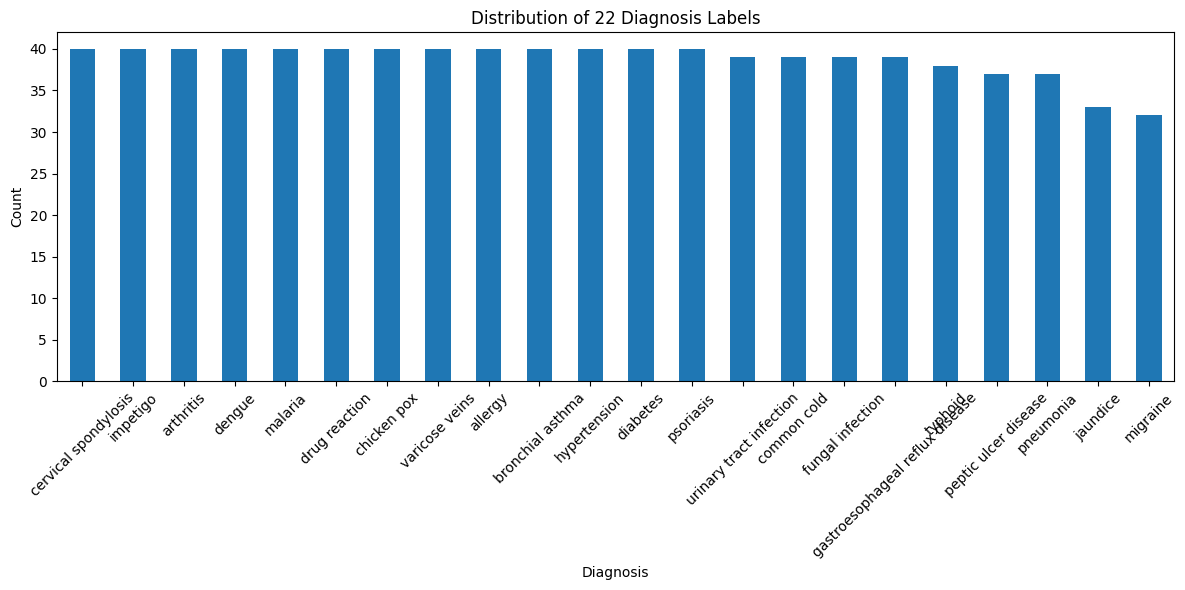


--- Count of each diagnosis ---
diagnosis
cervical spondylosis               40
impetigo                           40
arthritis                          40
dengue                             40
malaria                            40
drug reaction                      40
chicken pox                        40
varicose veins                     40
allergy                            40
bronchial asthma                   40
hypertension                       40
diabetes                           40
psoriasis                          40
urinary tract infection            39
common cold                        39
fungal infection                   39
gastroesophageal reflux disease    39
typhoid                            38
peptic ulcer disease               37
pneumonia                          37
jaundice                           33
migraine                           32
Name: count, dtype: int64

Imbalance Ratio (Majority Class / Minority Class): 1.25

--- 5 rows from each triage level ---

,symptom_text,diagnosis,triage_level
0,I've been having a lot of pain in my neck and ...,cervical spondylosis,WAIT
1,I have a rash on my face that is getting worse...,impetigo,WAIT
3,I have been having trouble with my muscles and...,arthritis,WAIT
5,I've been feeling really run down and weak. My...,common cold,WAIT
8,I have a rash around my nose that is red and i...,impetigo,WAIT



DOCTOR Triage Level Samples:


,symptom_text,diagnosis,triage_level
2,I have been urinating blood. I sometimes feel ...,urinary tract infection,DOCTOR
4,I have been feeling really sick. My body hurts...,dengue,DOCTOR
6,I have rashes all over my body. I also have a ...,dengue,DOCTOR
7,I have been feeling nauseous and have a consta...,dengue,DOCTOR
9,I have a rash on my chest and back and it itch...,drug reaction,DOCTOR



ER Triage Level Samples:


,symptom_text,diagnosis,triage_level
31,I've been feeling really sick lately. I've bee...,pneumonia,ER
36,I'm having trouble breathing and have a fever....,pneumonia,ER
82,I'm having trouble breathing and I'm sweating ...,pneumonia,ER
91,"I've been feeling really run down and achy, an...",pneumonia,ER
144,I've been feeling really cold and tired lately...,pneumonia,ER


In [6]:
# -- Distribution of diagnosis labels (Task 1.3.1) -------------------------

# FILL IN: plot the diagnosis-label distribution as a bar chart
#   (df['diagnosis'].value_counts().plot(kind='bar', ...)); label the axes
#   and title it with the number of labels.
import matplotlib.pyplot as plt

# Plot the diagnosis-label distribution
fig, ax = plt.subplots(figsize=(12, 6))
df['diagnosis'].value_counts().plot(kind='bar', ax=ax)
ax.set_title(f'Distribution of {df["diagnosis"].nunique()} Diagnosis Labels')
ax.set_xlabel('Diagnosis')
ax.set_ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# FILL IN (comment): which 3 diagnoses are most common, and what does that
#   class imbalance mean for how you evaluate the agent?
# The 3 most common diagnoses are:
# 1. Cervical Spondolytis
# 2. Arthritis
# 3. Malaria
# This class imbalance means that an agent might perform well by simply predicting these common diagnoses, but could struggle with rarer conditions. For evaluation, this implies that overall accuracy might be high due to correctly classifying frequent cases, but recall for less common or critical conditions (like 'ER' level diagnoses) might be low, which is a significant safety concern.
#print  count of each diagnosis
print("\n--- Count of each diagnosis ---")
print(df['diagnosis'].value_counts())

#Check imbalance ratio IR
dx_counts = df['diagnosis'].value_counts()
max_count = dx_counts.max()
min_count = dx_counts.min()
imbalance_ratio = max_count / min_count
print(f"\nImbalance Ratio (Majority Class / Minority Class): {imbalance_ratio:.2f}")
#1.25 imbalance is relatively mild

# Print 5 rows from each triage level
print("\n--- 5 rows from each triage level ---")
for level in df['triage_level'].unique():
    print(f"\n{level} Triage Level Samples:")
    display(df[df['triage_level'] == level].head(5))

<!-- TASKMARK -->
## Task 1.4 — Construct Ground Truth and Evaluation Sample
### **1.4.1** Review the diagnosis → triage mapping <font color="red">[4 marks]</font>

Spot-check the given map; write a clinical justification for ≥3 ambiguous calls.

## Day 1-2: Review the Triage Map (your ground truth)

The diagnosis -> WAIT / DOCTOR / ER map is **given** in `data_loader.py` as `TRIAGE_MAP`.
You do **not** build it. Your job is to *understand and sanity-check* it, because every
metric in all the notebooks are measured against this map.

How the three levels are defined:
- **ER**: life-threatening within hours (heart attack, brain hemorrhage, pneumonia)
- **DOCTOR**: needs clinical review, not immediately life-threatening (UTI, diabetes, jaundice)
- **WAIT**: manageable without a doctor visit today (mild cold, fungal infection, mild acne)

**Your graded task (1.4.1):** display the map, spot-check ~5 cases per level (next cells),
then write a one-line clinical justification for **3 ambiguous calls** -- e.g. *why is
jaundice DOCTOR and not ER?* Fill these into the justifications cell below.

In [7]:
# -- TRIAGE_MAP -- GIVEN ------------------------------------------------------
# Maps 41 known diagnosis names to WAIT / DOCTOR / ER (current dataset uses 22).
# ER = immediate emergency  |  DOCTOR = same-day review  |  WAIT = home care
#
# Your score_severity() rules in the cells below must be consistent with this
# map -- read it before you write a single line of scoring logic.
from data_loader import TRIAGE_MAP

# Display as a DataFrame so you can sort and scan it
import pandas as pd
pd.DataFrame(list(TRIAGE_MAP.items()), columns=["diagnosis","triage_level"]).sort_values("triage_level")


,diagnosis,triage_level
20,Hepatitis B,DOCTOR
25,Tuberculosis,DOCTOR
24,Alcoholic hepatitis,DOCTOR
23,Hepatitis E,DOCTOR
22,Hepatitis D,DOCTOR
21,Hepatitis C,DOCTOR
31,Hypothyroidism,DOCTOR
32,Hyperthyroidism,DOCTOR
18,Typhoid,DOCTOR
17,Dengue,DOCTOR


Triage distribution:
triage_level
WAIT      429
DOCTOR    387
ER         37
Name: count, dtype: int64


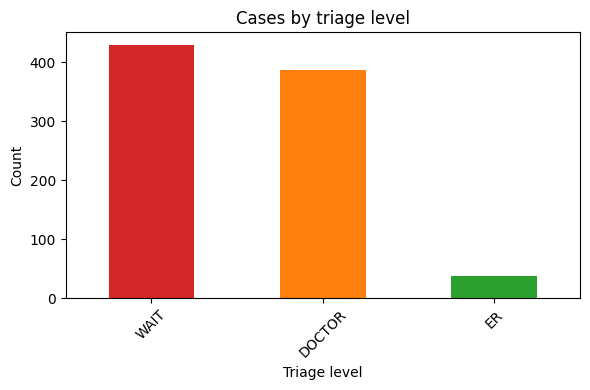

In [8]:
# Triage distribution -- the loader already provides triage_level via the
# case-insensitive canonical TRIAGE_MAP (plus aliases for renamed diseases).
print('Triage distribution:')
print(df['triage_level'].value_counts())

fig, ax = plt.subplots(figsize=(6, 4))
df['triage_level'].value_counts().plot(kind='bar', ax=ax,
    color=['#d62728', '#ff7f0e', '#2ca02c'])
ax.set_title('Cases by triage level')
ax.set_xlabel('Triage level')
ax.set_ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# FILL IN: which class is smallest? why does this matter for ER recall?
#ANSWER: ER class is smallest. For the ER class, recall is especially important as it measures the proportion of
#actual ER cases that were correctly identified, minimizing under-triage


In [20]:
# -- Spot-check 5 rows from each triage level -----------------------------
# FILL IN: replace this comment with pd.concat + sample(5) for each level
# Goal: verify the mapping looks sensible for each class

for level in ['ER', 'DOCTOR', 'WAIT']:
    sample = df[df['triage_level'] == level].sample(min(5, len(df[df["triage_level"] == level])), random_state=42)
    print(f'\n-- {level} examples --')
    for _, row in sample.iterrows():
        print(f'  [{row["diagnosis"]}] {str(row["symptom_text"])[:80]}...')

# --- YOUR JUSTIFICATIONS (graded 1.4.1) ----------------------------------
# Pick 3 diagnoses whose WAIT/DOCTOR/ER call is debatable and defend each in one line.
# Example -> "Jaundice": "DOCTOR not ER: usually hepatitis/gallstones, time-sensitive but not hours-to-die"
triage_map_justifications = {
    "Hypertension":"ER not DOCTOR:  Chest pain together with dizziness and headache could indicate a hypertensive emergency, heart attack, or stroke. Chest pain should not be routinely classified as a doctor visit without assessing severity. It should be ER.",
    "Migraine":"DOCTOR not WAIT:  Stiff neck is a potential sign of meningitis or other serious neurological conditions.",
    "GERD":"DOCTOR not WAIT: Repeated vomiting after meals is an alarm symptom that requires medical assessment."
}
for _dx, _why in triage_map_justifications.items():
    print(f"{_dx}: {_why}")


-- ER examples --
  [pneumonia] I'm feeling really hot. I can't breathe well. I'm sweating a lot. I'm shaking. I...
  [pneumonia] I'm having trouble breathing and I feel really uncomfortable. I'm sweating a lot...
  [pneumonia] I've been feeling really cold and tired lately. I've been coughing a lot, and it...
  [pneumonia] I'm having trouble breathing and I feel really uncomfortable. I'm sweating a lot...
  [pneumonia] I've been feeling really run down lately. I've had a cough that just won't go aw...

-- DOCTOR examples --
  [bronchial asthma] I've been having trouble breathing, coughing a lot, and running a fever. I've al...
  [malaria] I've been having a fever, chills, and nausea. I've also been sweating a lot and ...
  [hypertension] I've been having chest pain, dizziness, and a headache that feels like it's in a...
  [peptic ulcer disease] I have trouble swallowing food and it feels like food is getting stuck in my thr...
  [hypertension] I've been feeling unwell for a while now

<!-- TASKMARK -->
### **1.4.2** Create the fixed evaluation sample <font color="red">[3 marks]</font>

Create a stratified n=50 sample with a fixed seed and state the train/test discipline.

## Day 3-4: Fixed Evaluation Sample

**Lock this now. Do not change it.**

`build_evaluation_dataset(n=50, seed=42)` gives a stratified sample:
proportional representation of WAIT / DOCTOR / ER.

All accuracy numbers in the next notebooks use this same 50 cases.
This prevents you from improving the score by cherry-picking easier cases.

**How the split works (the only data discipline you need):** the dataset has 853
labeled cases. These 50 (seed=42) are your **held-out test set** -- you never tune on
them. The remaining cases are free for calibration in `agent_evaluation_and_optimisation.ipynb`. There is no separate file
to download; this locked sample *is* the capstone's test set.

In [21]:
# -- build_evaluation_dataset() -- GIVEN ---------------------------------------
# Returns exactly 50 cases, stratified across WAIT / DOCTOR / ER.
# Columns: symptom_text, diagnosis, triage_level
#
# LOCK: always use n=50, seed=42. This benchmark never changes.
# All four notebooks measure against this same set so numbers are comparable.
from data_loader import build_evaluation_dataset

eval_df = build_evaluation_dataset(n=50, seed=42)  # LOCK -- do not change seed
print("Evaluation set shape:", eval_df.shape)
print(eval_df["triage_level"].value_counts())
eval_df.head(3)


Evaluation set shape: (50, 3)
triage_level
WAIT      17
DOCTOR    17
ER        16
Name: count, dtype: int64


,symptom_text,diagnosis,triage_level
0,I have been experiencing cramps in my legs for...,varicose veins,WAIT
1,I'm having trouble breathing. I'm coughing up ...,pneumonia,ER
2,I have a burning pain in my stomach that comes...,peptic ulcer disease,DOCTOR


<!-- TASKMARK -->
# Stage 2 — Baseline System <font color="red">[10 marks]</font>
## Task 2.1 — Transparent Policy Baseline
### **2.1.1** Evaluate the baseline <font color="red">[4 marks]</font>

Implement the keyword/rule baseline and evaluate it on the fixed sample; report accuracy and per-class recall.

## Day 3-4: Policy Baseline

Before building the ADK agent, run the transparent rule-based policy.
This is your **baseline** -- a concrete number to beat in the next notebook `agent_pipeline_development.ipynb`.

The policy does NOT call Gemini. It runs entirely offline.
This proves you can test the triage logic without spending API quota.

### Anatomy of a Policy Trace

Every call to `run_policy_triage(text)` returns a dict with these keys.
Read this before running the baseline -- you will be asked to interpret each field.

| Key | Type | What it contains |
|-----|------|------------------|
| `patient_input` | str | The original text you passed in |
| `symptoms` | list[str] | Extracted visible symptoms, e.g. `['fever', 'duration:3 days']` |
| `clinical_context` | dict | Red flag groups and vulnerability flags detected |
| `severity_json` | dict | `{severity: 1-5, reason: '...'}` -- the urgency score |
| `followup` | dict | `{needed: bool, question: str|null}` -- clarifying question if ambiguous |
| `triage_decision` | dict | `{triage_level: 'WAIT'|'DOCTOR'|'ER', rule_applied: '...'}` |
| `predicted_triage` | str | Just the label -- `'WAIT'`, `'DOCTOR'`, or `'ER'` |
| `final_response` | str | The full Priya-ready response including disclaimer |
| `safety_audit` | dict | `{verdict, risk_level, violations, human_review_needed, stage_to_debug, reason}` |

> **Key insight**: `predicted_triage` == `triage_decision['triage_level']`.
> They are the same value -- one is for convenience, one is for the full audit trail.
> In `agent_evaluation_and_optimisation.ipynb` you will compare `predicted_triage` against `true_triage` for 50 cases.


In [22]:
# -- sahayak_starter.py -- YOUR FILE -------------------------------------------
# run_policy_triage() is one of the THREE functions you will build in this notebook.
# Right now it raises NotImplementedError -- this cell will crash until you
# implement it.
#
# How to fix:
#   1. Open sahayak_starter.py in this folder
#   2. Implement score_severity()    (reads the urgency rubric from its docstring)
#   3. Implement decide_triage()     (maps severity score -> WAIT/DOCTOR/ER)
#   4. Implement run_policy_triage() (calls the above in the order its docstring shows)
#   5. Save sahayak_starter.py, come back, re-run this cell
#
# If stuck: re-read each function's docstring -- it spells out the exact steps
#           in order. Build them one at a time, re-running this cell as you go.

import os

# Check if sahayak_starter.py exists, if not, download it
if not os.path.exists('sahayak_starter.py'):
    !wget -q https://raw.githubusercontent.com/kumarsirish/capstone-b/main/starter-files/learner/sahayak_starter.py
    print('Downloaded sahayak_starter.py')
else:
    print('sahayak_starter.py already exists.')

from sahayak_starter import run_policy_triage

# Run a single case to see full intermediate output
example = "Patient has chest pain, sweating, and difficulty breathing."
result = run_policy_triage(example)
for k, v in result.items():
    print(f"{k}: {v}")


sahayak_starter.py already exists.
patient_input: Patient has chest pain, sweating, and difficulty breathing.
symptoms: ['chest pain', 'difficulty breathing', 'sweating']
severity_json: {'severity': 5, 'reason': 'Chest pain with breathlessness/sweating is an emergency cardiac or respiratory pattern.'}
followup: {'needed': False, 'question': None}
triage_decision: {'triage_level': 'ER', 'rule_applied': 'severity 5 -> ER'}
predicted_triage: ER
final_response: Based on what you described, I recommend: Go to the ER now. The main reason is: Chest pain with breathlessness/sweating is an emergency cardiac or respiratory pattern. Clinical safety note: Emergency red flags need immediate escalation rather than home monitoring. Key symptoms noted: chest pain, difficulty breathing, sweating. Next step: keep the patient comfortable and follow the recommended care level. This is decision support guidance only. Always consult a qualified medical professional for diagnosis and treatment.
safety_audit:

In [12]:
import os
import sahayak_starter # Import the module itself

# Provide a placeholder for safety_evaluator_agent when SAHAYAK_ENV is BASELINE
def _safety_evaluator_agent_placeholder(patient_input, symptoms, severity_json, triage_decision, final_response, expected_triage=None):
   return {
            "verdict": "pass",
            "risk_level": "low",
            "violations": [],
            "human_review_needed": False,
            "stage_to_debug": "none",
            "reason": "Placeholder for baseline environment"
        }

# Assign the placeholder directly to the module's attribute
sahayak_starter.safety_evaluator_agent = _safety_evaluator_agent_placeholder

# Now call run_policy_evaluation from the module
results_df, metrics = sahayak_starter.run_policy_evaluation(n=50, seed=42)

print("=== Baseline Metrics ===")
for k, v in metrics.items():
    print(f"  {k}: {v}")

=== Baseline Metrics ===
  er_recall: 0.0
  under_triage_rate: 0.54
  accuracy: 0.44
  wait_precision: 0.41
  doctor_f1: 0.429
  recall_by_triage: {'WAIT': 0.9411764705882353, 'DOCTOR': 0.35294117647058826, 'ER': 0.0}
  safety_utility: 0.176
  safety_gate: FAIL
  n_cases: 50
  evaluator_pass_rate: 0.0
  human_review_rate: 0.0


<!-- TASKMARK -->
### **2.1.2** Explain the failure mode <font color="red">[2 marks]</font>

Name the dominant failure mode with ≥2 concrete misclassified examples (rules collapse on natural language; ER recall ≈ 0).

In [25]:
# -- Build the trace table ------------------------------------------------
# The trace table is your primary debugging artifact for `agent_pipeline_development.ipynb`.
# It shows: input, predicted, true label, correct?, evaluator verdict

# under_triage: True when predicted_urgency < true_urgency
# Urgency order: WAIT=0, DOCTOR=1, ER=2
# Predicting WAIT for an ER case is under_triage -- the safety-critical error.
# You will count and analyse these in `agent_evaluation_and_optimisation.ipynb`.
trace_cols = ['patient_input', 'diagnosis', 'true_triage', 'predicted_triage',
              'correct', 'evaluator_verdict', 'evaluator_violations']

trace_table = results_df[trace_cols].copy()

# Show failures only
failures = trace_table[~trace_table['correct']]
print(f'Failures: {len(failures)} / {len(trace_table)}')
# FILL IN: add an under_triage column to trace_table
# under_triage = True when predicted urgency is lower than true urgency
# Urgency order: WAIT=0, DOCTOR=1, ER=2
# You will count under-triage cases again in `agent_evaluation_and_optimisation.ipynb` as the primary safety metric.
# Hint:
#   urgency = {"WAIT": 0, "DOCTOR": 1, "ER": 2}
#   trace_table["under_triage"] = ???
urgency_map = {"WAIT": 0, "DOCTOR": 1, "ER": 2}
trace_table["predicted_urgency_score"] = trace_table["predicted_triage"].map(urgency_map)
trace_table["true_urgency_score"] = trace_table["true_triage"].map(urgency_map)
trace_table["under_triage"] = trace_table["predicted_urgency_score"] < trace_table["true_urgency_score"]

under_triage_count = trace_table["under_triage"].sum()
print(f"Under-triage cases: {int(under_triage_count)}")
failures.head(10)


Failures: 28 / 50
Under-triage cases: 27


,patient_input,diagnosis,true_triage,predicted_triage,correct,evaluator_verdict,evaluator_violations
1,I'm having trouble breathing. I'm coughing up ...,pneumonia,ER,WAIT,False,pass,[]
2,I have a burning pain in my stomach that comes...,peptic ulcer disease,DOCTOR,WAIT,False,pass,[]
3,"I'm burning up, and I can't catch my breath. I...",pneumonia,ER,WAIT,False,pass,[]
6,I have trouble breathing when I exercise. I sw...,diabetes,DOCTOR,WAIT,False,pass,[]
8,I'm feeling really hot. I can't breathe well. ...,pneumonia,ER,WAIT,False,pass,[]
9,I have trouble swallowing food and it feels li...,peptic ulcer disease,DOCTOR,WAIT,False,pass,[]
12,I'm sweating a lot and can't catch my breath. ...,pneumonia,ER,WAIT,False,pass,[]
16,I've been feeling really unwell recently. I've...,pneumonia,ER,WAIT,False,pass,[]
17,I'm having trouble breathing. I'm sweating and...,pneumonia,ER,WAIT,False,pass,[]
18,I've been feeling really sick for the past few...,pneumonia,ER,DOCTOR,False,pass,[]


## Task 2.2 — First Two ADK Stages (Parser + Severity)

### **2.2.1** Build parser + severity scorer <font color="red">[4 marks]</font>

Implement `symptom_parser` and `severity_scorer` as `LlmAgent`s; run them over ≥10 cases and show a trace table (input → symptoms → severity → expected vs predicted).

Now build your **first two ADK agents**. These are the two simplest stages of the
six-agent pipeline; in **`agent_pipeline_development.ipynb` you will reuse them** and add the other four.

- **`symptom_parser`** — turns free-text into a JSON list of symptoms (`output_key="symptoms"`)
- **`severity_scorer`** — scores urgency 1–5 from those symptoms (`output_key="severity_json"`)

Run them over ≥10 evaluation cases and produce a **trace table**:
`input → symptoms → severity → expected vs predicted`.

In [33]:
# -- 2.2 Parser + Severity: ADK setup (GIVEN) --------------------------------
!pip -q install google-adk[extensions]
import os, asyncio, json as _json
import nest_asyncio; nest_asyncio.apply()
from google.adk.agents import LlmAgent, SequentialAgent
from google.adk.runners import Runner
from google.adk.sessions import InMemorySessionService
from google.genai.types import Content, Part
#from google.colab import userdata
from google.adk.models.lite_llm import LiteLlm

# Check if utils.py exists, if not, download it
if not os.path.exists('utils.py'):
    !wget -q https://raw.githubusercontent.com/kumarsirish/capstone-b/main/starter-files/learner/utils.py
    print('Downloaded utils.py')
else:
    print('utils.py already exists.')

# Check if sahayak_starter.py exists, if not, download it
if not os.path.exists('sahayak_starter.py'): # Add check for sahayak_starter.py if needed, as it was in previous versions
    !wget -q https://raw.githubusercontent.com/kumarsirish/capstone-b/main/starter-files/learner/sahayak_starter.py
    print('Downloaded sahayak_starter.py')
else:
    print('sahayak_starter.py already exists.')

from sahayak_starter import run_policy_triage

# Retrieve API key from Colab secrets.
#GOOGLE_API_KEY = userdata.get('GOOGLE_API_KEY')

# Set API key as environment variable for LiteLLM. This is how LiteLLM usually picks up the key.
#os.environ['GOOGLE_API_KEY'] = GOOGLE_API_KEY

# Set environment variable to explicitly not use Vertex AI, if LiteLLM tries to default to it.
os.environ['GOOGLE_GENAI_USE_VERTEXAI'] = 'FALSE'

# Initialize the Gemini model using LiteLlm wrapper.
try:
    # LiteLlm will use the GOOGLE_API_KEY from os.environ, and the 'gemini/' prefix ensures direct Gemini API usage.
    MODEL = LiteLlm(model="gemini/gemini-2.5-flash")
    print("Gemini model initialized successfully using LiteLlm.")
except Exception as e:
    print(f"Error initializing LiteLlm for Gemini: {e}")
    print("Please check your GOOGLE_API_KEY in Colab secrets and ensure the model ('gemini/gemini-2.5-flash') is available and accessible via LiteLLM.")
    raise # Re-raise to indicate failure

print(f"Model {MODEL} ready for the first two agents.")

utils.py already exists.
sahayak_starter.py already exists.
Gemini model initialized successfully using LiteLlm.
Model model='gemini/gemini-2.5-flash' llm_client=<google.adk.models.lite_llm.LiteLLMClient object at 0x7814e92e5a60> ready for the first two agents.


In [34]:
# -- 2.2 Parser + Severity: YOUR TWO AGENTS ----------------------------------
# Write the instruction for each agent. Use {patient_input} / {symptoms} to read
# from session state, and keep the output a single JSON object/array.
import pprint

PARSER_INSTRUCTION = """
You are a clinical data extractor. Your ONLY job is to extract symptoms from a patient description.

Rules:
1. Return ONLY a JSON list of strings e.g. ["fever","headache"]. No other text.
2. Include duration if mentioned, e.g. "duration:3 days".
3. Include intensity if mentioned, e.g. "severity:high".
4. DO NOT diagnose. DO NOT add symptoms not in the text.
5. If no symptoms are present, return [].

Patient input: {patient_input}
"""

SEVERITY_INSTRUCTION = """

You are a clinical severity scorer. Your ONLY job is to assign an urgency score from 1 to 5 based on the symptoms provided, using the fixed rules below. You must NOT freely decide the score or invent your own criteria -- apply the rules exactly as written.

Rules:
- Score 5: chest pain with breathing trouble, altered sensorium, one-sided weakness, or fainting.
- Score 4: high fever with stiff neck, jaundice signs, persistent vomiting, or urinary symptoms.
- Score 3: moderate fever, headache, or a single vomiting episode.
- Score 2: mild rash, mild cough, or joint/muscle ache without red flags.
- Score 1: no active symptoms.

Return ONLY this JSON object, no other text: {{"severity": 1-5, "reason": "one sentence"}}
Symptoms: {symptoms}

"""

symptom_parser = LlmAgent(name="symptom_parser", model=MODEL,
                          instruction=PARSER_INSTRUCTION, output_key="symptoms")
severity_scorer = LlmAgent(name="severity_scorer", model=MODEL,
                           instruction=SEVERITY_INSTRUCTION, output_key="severity_json")
print("Defined symptom_parser + severity_scorer.")
pprint.pp(severity_scorer)

Defined symptom_parser + severity_scorer.
LlmAgent(name='severity_scorer', description='', rerun_on_resume=False, wait_for_output=False, retry_config=None, timeout=None, input_schema=None, output_schema=None, state_schema=None, parent_agent=None, sub_agents=[], before_agent_callback=None, after_agent_callback=None, model=LiteLlm(model='gemini/gemini-2.5-flash', llm_client=<google.adk.models.lite_llm.LiteLLMClient object at 0x7814e92e5a60>), instruction='\n\nYou are a clinical severity scorer. Your ONLY job is to assign an urgency score from 1 to 5 based on the symptoms provided, using the fixed rules below. You must NOT freely decide the score or invent your own criteria -- apply the rules exactly as written.\n\nRules:\n- Score 5: chest pain with breathing trouble, altered sensorium, one-sided weakness, or fainting.\n- Score 4: high fever with stiff neck, jaundice signs, persistent vomiting, or urinary symptoms.\n- Score 3: moderate fever, headache, or a single vomiting episode.\n- Sco

In [35]:
# -- 2.2 Parser + Severity: run on >=10 cases -> trace table (GIVEN) ----------
APP = "sahayak_w2_2_2"
_svc = InMemorySessionService()
_pipe = SequentialAgent(name="parse_then_score", sub_agents=[symptom_parser, severity_scorer])
_runner = Runner(agent=_pipe, app_name=APP, session_service=_svc)

async def _parse_score(text, i):
    sid = f"s{i}"
    await _svc.create_session(app_name=APP, user_id="priya", session_id=sid,
                              state={"patient_input": text, "symptoms": "", "severity_json": ""})
    msg = Content(role="user", parts=[Part(text=text)])
    async for _ in _runner.run_async(user_id="priya", session_id=sid, new_message=msg):
        pass
    st = (await _svc.get_session(app_name=APP, user_id="priya", session_id=sid)).state
    return st.get("symptoms", ""), st.get("severity_json", "")

def _sev(s):
    try: return int(_json.loads(str(s).strip().removeprefix("```json").removeprefix("```").removesuffix("```")).get("severity"))
    except Exception:
        import re; m = re.search(r'"?severity"?\s*[:=]\s*([1-5])', str(s)); return int(m.group(1)) if m else None

sample = build_evaluation_dataset(n=12, seed=42)
rows = []
for i, (_, r) in enumerate(sample.iterrows()):
    try:
        sym, sev = asyncio.run(_parse_score(r["symptom_text"], i))
    except Exception as e:
        sym, sev = f"ERROR: {e}", ""
    rows.append({"input": r["symptom_text"][:45], "symptoms": str(sym)[:45],
                 "severity": _sev(sev), "expected_triage": r["triage_level"]})
trace_22 = pd.DataFrame(rows)
print(f"Parser+Severity trace table ({len(trace_22)} rows):")
trace_22

Parser+Severity trace table (12 rows):


,input,symptoms,severity,expected_triage
0,I've been feeling really cold and tired latel,"```json\n[\n ""cold sensation"",\n ""tiredness"",\n",5,ER
1,I'm having trouble breathing and I feel reall,"```json\n[\n ""trouble breathing"",\n ""uncomfort",5,ER
2,"I've been having back pain, a chronic cough,","[""back pain"", ""chronic cough"", ""muscle weakne",5,WAIT
3,I'm feeling really hot. I can't breathe well.,"[""feeling hot, severity:really"",""difficulty b",3,ER
4,"I've been having a fever, chills, and nausea.","```json\n[\n ""fever"",\n ""chills"",\n ""nausea...",3,DOCTOR
5,"I have a stiff neck and eye issues, and I've","[""stiff neck"", ""eye issues"", ""hungry all the",2,WAIT
6,"I have been having back pain, a lingering cou","[""back pain"", ""cough"", ""muscle weakness"", ""di",2,WAIT
7,I'm having trouble breathing and I feel reall,"```json\n[\n ""trouble breathing"",\n ""uncomfort",5,ER
8,"I've been having trouble breathing, coughing","```json\n[\n ""trouble breathing"",\n ""coughing""",3,DOCTOR
9,I have trouble swallowing food and it feels l,"```json\n[\n ""trouble swallowing food"",\n ""foo",2,DOCTOR


## Part 2 · The 4 FunctionTools — What Makes the Agent "Agentic"

> **The key idea:** a plain LLM call takes text and returns text — it can only use
> what is baked into its weights. An *agent* can call external systems mid-reasoning,
> observe the real result, and decide again. That loop is what makes it agentic.

Sahayak Health AI gives its `triage_decider` four tools. Each does something a raw
LLM prompt *cannot do reliably*:

| Tool | Why a prompt can't replace it |
|---|---|
| `search_symptom_cases_db` | DB evidence is factual and *retrieved* — not generated from memory |
| `lookup_drug_safety` | Drug labels change; a hallucinated warning is a patient risk |
| `parse_vitals_from_text` | LLMs invent numbers; vitals must be extracted, not guessed |
| `calculate_india_news2` | Wrong arithmetic = wrong escalation = unsafe triage |

These 4 tools are **GIVEN** to you in `sahayak_tools.py` (do not modify them). In this notebook,
you study what each returns. In **`agent_pipeline_development.ipynb`** you wrap each as a `FunctionTool` and
hand them to the agent — ADK reads every function's **type hints + docstring** and
auto-generates the JSON schema that tells the LLM *when* and *how* to call it.

### Tool 1 · `search_symptom_cases_db` — Hybrid RAG over real cases

You already know RAG: fetch relevant context, inject it into the prompt. Here the
"context" is real triage decisions from 500 past cases in `cases.db`. Getting
retrieval right meant fixing four concrete failures:

| Problem | What went wrong | Fix |
|---|---|---|
| Query–doc asymmetry | *"I can't catch my breath"* never matches *"shortness of breath"* | rewrite query to canonical terms first |
| Fake consensus | top-3 returned the same row 3× — one case voting with itself | deduplicate 500 → unique case groups |
| Unweighted vote | distant matches counted as much as close ones | similarity-weighted vote |
| Vocabulary blindness | *"shaking"*, *"racing heart"* mapped to nothing | 11-term synonym dictionary |

Final hybrid score:

```
score = 0.5 × Jaccard symptom overlap   (sparse — exact canonical terms)
      + 0.5 × cosine similarity          (dense  — semantic embedding)
```

It returns a **consensus decision** + **confidence**, and — crucially — **honestly
abstains** when symptoms fall outside its vocabulary, so the agent falls back to
NEWS2 + clinical judgment instead of guessing.

### Tool 2 · `lookup_drug_safety` — Live FDA drug-label lookup

When a patient names a medication, the agent must not *invent* safety information.
This tool queries the live **openFDA** drug-label API and is **India-aware**: it maps
Indian brand names (Crocin, Calpol) to their generic (paracetamol) before querying,
and flags India-only drugs (e.g. nimesulide) that aren't in the FDA database.

> Needs internet. If openFDA is unreachable, the tool degrades gracefully and the
> agent simply proceeds without a drug flag.

### Tool 3 · `parse_vitals_from_text` — Deterministic vital extraction

ASHA workers reply in natural language: *"temperature is 38.6, oxygen 93%, counted
112 beats"*. This tool pulls the numbers out with **regex — not the LLM** — because a
hallucinated vital would corrupt the NEWS2 score. It auto-converts °F→°C, handles unit
ambiguity, and returns `null` for missing values so NEWS2 degrades gracefully to
partial scoring.

### Tool 4 · `calculate_india_news2` — Validated clinical score

**NEWS2** (National Early Warning Score 2, Royal College of Physicians UK 2017) is a
validated deterioration score, also validated in Indian hospitals. Six vitals → an
integer score → an escalation level:

| Score | Escalation | Risk |
|---|---|---|
| 0    | WAIT   | Low |
| 1–4  | DOCTOR | Low–Medium |
| 5–6  | ER     | High |
| ≥ 7  | ER     | Critical |

**India-specific additions** beyond standard NEWS2:
- SpO2 ≤ 94% → MOHFW ASHA advisory threshold
- Fever ≥ 38.5°C + monsoon → +1 (malaria / dengue risk)
- Temp > 40°C + heat wave → ER flag (heat stroke)
- Pregnant / elderly → escalate one level

This is deterministic arithmetic: the LLM must **call** it, never approximate it.

In [17]:
# -- The 4 FunctionTools in action (all four demos in one cell) --------------
# These GIVEN tools are what your `agent_pipeline_development.ipynb`` triage_decider will call. Read the
# four explanations above, then run this single cell to see each one's output.

if not os.path.exists('sahayak_tools.py'): # Add check for sahayak_starter.py if needed, as it was in previous versions
    !wget -q https://raw.githubusercontent.com/kumarsirish/capstone-b/main/starter-files/learner/sahayak_tools.py
    print('Downloaded sahayak_tools.py')
else:
    print('sahayak_tools.py already exists.')

from sahayak_tools import (search_symptom_cases_db, lookup_drug_safety,
                           parse_vitals_from_text, calculate_india_news2)

print("\n" + "=" * 60)
print("Tool 1 · search_symptom_cases_db — Hybrid RAG over real cases")
print("=" * 60)
# Case 1 — clear ER presentation
r = search_symptom_cases_db("I can't breathe and my chest is really hurting. I'm sweating.")
print("Case 1: chest pain + breathing trouble")
print(f"  extracted symptoms : {r.get('extracted_symptoms')}")
print(f"  consensus          : {r.get('consensus_decision')}  (confidence {r.get('consensus_confidence')})")
print(f"  weighted votes     : {r.get('vote_breakdown')}")
print(f"  evidence from      : {r.get('n_underlying_cases')} underlying cases")
print()

# Case 2 — colloquial language (the vocabulary-blindness fix)
r2 = search_symptom_cases_db("She is burning up and shaking, heart is racing, can't stop coughing")
print("Case 2: 'burning up', 'shaking', 'racing heart'  (no canonical terms)")
print(f"  extracted symptoms : {r2.get('extracted_symptoms')}")
print(f"  consensus          : {r2.get('consensus_decision')}  (confidence {r2.get('consensus_confidence')})")
print()

# Case 3 — honest abstention (outside the 11-term vocabulary)
r3 = search_symptom_cases_db("I have varicose veins in my legs, they are swollen")
print("Case 3: varicose veins (outside DB vocabulary)")
print(f"  status  : {r3.get('status')}")
print(f"  message : {r3.get('message')}")
print("  -> agent falls back to NEWS2 + clinical judgment (correct behaviour)")

print("\n" + "=" * 60)
print("Tool 2 · lookup_drug_safety — live FDA drug-label lookup")
print("=" * 60)
# Indian brand -> generic normalisation
r = lookup_drug_safety("crocin")
print("Drug: Crocin  ->  generic:", r.get('fda_generic_name', r.get('drug_queried')))
print("  status   :", r.get('status'))
print("  warnings :", str(r.get('warnings', ''))[:160])
print()

# India-only drug not in the FDA database
r2 = lookup_drug_safety("nimesulide")
print("Drug: Nimesulide")
print("  status    :", r2.get('status'))
print("  risk_level:", r2.get('risk_level'))
print("  note      :", str(r2.get('warnings') or r2.get('note', ''))[:200])

print("\n" + "=" * 60)
print("Tool 3 · parse_vitals_from_text — deterministic vital extraction")
print("=" * 60)
tests = [
    "temp 38.6, spo2 93%, pulse 112, breathing 22 times per minute",
    "102 F, oxygen 94 percent, pulse 98 beats",
    "she is unconscious, I could not check anything",
    "BP is 90/60, feels very cold, no thermometer available",
]
for t in tests:
    v = parse_vitals_from_text(t)
    print(f"Input : {t[:58]}")
    print(f"Output: temp={v.get('temp_c')}C  spo2={v.get('spo2')}%  hr={v.get('heart_rate')}  "
          f"rr={v.get('resp_rate')}  bp={v.get('systolic_bp')}  conscious={v.get('consciousness')}")
    print()

print("\n" + "=" * 60)
print("Tool 4 · calculate_india_news2 — validated clinical score")
print("=" * 60)
# A — high-risk vitals
n = calculate_india_news2(resp_rate=26, spo2=91, temp_c=39.4,
                          systolic_bp=95, heart_rate=118, consciousness="Alert")
print("A — high vitals")
print(f"  NEWS2 {n.get('news2_score')} | risk {n.get('risk_level')} | escalation {n.get('recommended_escalation')}")
print(f"  flags: {n.get('clinical_flags')}")
print()

# B — pregnant + monsoon context modifier
n2 = calculate_india_news2(resp_rate=18, spo2=94, temp_c=37.8, heart_rate=95,
                           consciousness="Alert", context_flags=["pregnant", "monsoon"])
print("B — pregnant + monsoon")
print(f"  NEWS2 {n2.get('news2_score')} | escalation {n2.get('recommended_escalation')} | "
      f"india modifiers {n2.get('india_modifiers_applied')}")
print()

# C — partial vitals + heat wave (common in rural ASHA setting)
n3 = calculate_india_news2(temp_c=40.2, spo2=93, context_flags=["heat_wave"])
print("C — 2 vitals + heat wave")
print(f"  NEWS2 {n3.get('news2_score')} | escalation {n3.get('recommended_escalation')} | flags {n3.get('clinical_flags')}")


Downloaded sahayak_tools.py

Tool 1 · search_symptom_cases_db — Hybrid RAG over real cases
Case 1: chest pain + breathing trouble
  extracted symptoms : None
  consensus          : None  (confidence None)
  weighted votes     : None
  evidence from      : None underlying cases

Case 2: 'burning up', 'shaking', 'racing heart'  (no canonical terms)
  extracted symptoms : None
  consensus          : None  (confidence None)

Case 3: varicose veins (outside DB vocabulary)
  status  : db_not_found
  message : Run 'python setup_db.py' once to build the case database.
  -> agent falls back to NEWS2 + clinical judgment (correct behaviour)

Tool 2 · lookup_drug_safety — live FDA drug-label lookup
Drug: Crocin  ->  generic: paracetamol
  status   : found
  warnings : WARNINGS Liver warning: This product contains acetaminophen. Severe liver damage may occur if your child takes: • More than 5 doses in 24 hours, which is the ma

Drug: Nimesulide
  status    : india_specific_drug
  risk_level: HIGH
 

In [18]:
# -- Bridge to `agent_pipeline_development.ipynb`: wrap each tool as an ADK FunctionTool -------------------
# The 4 functions above are plain Python. To let an LlmAgent CALL them, ADK needs
# a JSON schema for each. You never write that schema by hand -- wrapping a
# function in FunctionTool makes ADK read its signature + docstring for you.
# This is the EXACT wrapping you hand to triage_decider in `agent_pipeline_development.ipynb`.
import inspect
from google.adk.tools import FunctionTool
from sahayak_tools import (
    search_symptom_cases_db,
    lookup_drug_safety,
    parse_vitals_from_text,
    calculate_india_news2,
)

triage_tools = [
    FunctionTool(search_symptom_cases_db),
    FunctionTool(lookup_drug_safety),
    FunctionTool(parse_vitals_from_text),
    FunctionTool(calculate_india_news2),
]
print('Wrapped', len(triage_tools), 'Python functions as ADK FunctionTools.')
print()

# The schema ADK auto-generates from one signature (this is what the LLM sees):
print('ADK reads calculate_india_news2 signature to build its tool schema:')
for _name, _p in inspect.signature(calculate_india_news2).parameters.items():
    _ann = '' if _p.annotation is inspect._empty else ': ' + getattr(_p.annotation, '__name__', str(_p.annotation))
    _def = '' if _p.default is inspect._empty else ' = ' + repr(_p.default)
    print('  ' + _name + _ann + _def)
print()
print('Next notebook:  triage_decider = LlmAgent(..., tools=triage_tools)')
print('That one line is what turns an LLM into an AGENT.')

Wrapped 4 Python functions as ADK FunctionTools.

ADK reads calculate_india_news2 signature to build its tool schema:
  resp_rate: Optional[int] = None
  spo2: Optional[int] = None
  temp_c: Optional[float] = None
  systolic_bp: Optional[int] = None
  heart_rate: Optional[int] = None
  consciousness: str = 'Alert'
  context_flags: Optional[list] = None

Next notebook:  triage_decider = LlmAgent(..., tools=triage_tools)
That one line is what turns an LLM into an AGENT.


## Day 5: System Design Note

Write a one-page system design in the cell below.
Cover:
1. **Target user** -- who uses this and in what context?
2. **State schema** -- list all session.state keys and what they contain
3. **Node contracts** -- for each of the 6 agents: input state keys, output key, what it must/must not do
4. **Evaluation metric** -- what does 'better' mean? (accuracy? ER recall? evaluator pass rate?)
5. **Safety rules** -- what must never appear in the final response?

In [19]:
# -- YOUR SYSTEM DESIGN NOTE ----------------------------------------------

system_design = {
    'target_user': 'Priya, an ASHA (Accredited Social Health Activist) worker in rural India, needing quick triage decisions (WAIT/DOCTOR/ER) for patients based on symptom descriptions.',
    'state_schema': {
        'patient_input':   'The original natural-language symptom description provided by the patient.',
        'symptoms':        'A JSON list of distinct symptoms extracted from the patient_input, e.g., ["fever","headache"].',
        'severity_json':   'A JSON object with urgency score (1-5) and reason, e.g., {"severity": 3, "reason": "patient reports severe pain without other high-urgency symptoms"}.',
        'followup':        'A JSON object indicating if a clarifying question is needed and the question itself, e.g., {"needed": true, "question": "What is the severity of the chest pain?"}.',
        'triage_decision': 'A JSON object containing the final triage level (WAIT/DOCTOR/ER) and the rule applied, e.g., {"triage_level": "ER", "rule_applied": "NEWS2 score > 6"}.',
        'final_response':  'The complete, Priya-ready response to the patient, including the triage decision and a medical disclaimer.',
        'safety_audit':    'A JSON object containing the verdict of the safety evaluator, risk level, violations, human review need, debug stage, and reason for the audit, e.g., {"verdict": "pass", "risk_level": "low"}.'
    },
    'primary_metric':  'ER recall (to minimize under-triage) and evaluator pass rate (to ensure safety compliance).',
    'safety_rules': [
        'Never under-triage an ER case (i.e., predict WAIT or DOCTOR for an actual ER case).',
        'All drug safety information must be factual and retrieved from a reliable source (e.g., FDA database), not hallucinated by the LLM.',
        'Final responses must always include a medical disclaimer that it is decision support guidance only and not a substitute for professional medical advice.'
    ]
}

import json
print(json.dumps(system_design, indent=2))

{
  "target_user": "Priya, an ASHA (Accredited Social Health Activist) worker in rural India, needing quick triage decisions (WAIT/DOCTOR/ER) for patients based on symptom descriptions.",
  "state_schema": {
    "patient_input": "The original natural-language symptom description provided by the patient.",
    "symptoms": "A JSON list of distinct symptoms extracted from the patient_input, e.g., [\"fever\",\"headache\"].",
    "severity_json": "A JSON object with urgency score (1-5) and reason, e.g., {\"severity\": 3, \"reason\": \"patient reports severe pain without other high-urgency symptoms\"}.",
    "followup": "A JSON object indicating if a clarifying question is needed and the question itself, e.g., {\"needed\": true, \"question\": \"What is the severity of the chest pain?\"}.",
    "triage_decision": "A JSON object containing the final triage level (WAIT/DOCTOR/ER) and the rule applied, e.g., {\"triage_level\": \"ER\", \"rule_applied\": \"NEWS2 score > 6\"}.",
    "final_response

## Checkpoint

Tick each before moving to the next notebook `agent_pipeline_development.ipynb` :

- [ ] Dataset loaded; shape, missing values, and duplicates checked
- [ ] Reviewed the given triage map; justified 3 ambiguous calls (22 labels in the current release)
- [ ] Distribution plots created for diagnosis labels and triage levels
- [ ] Fixed evaluation sample created: `n=50, seed=42` -- **do not change**
- [ ] Policy baseline run; accuracy and ER recall recorded
- [ ] Trace table built; first 5 failures identified
- [ ] System design note complete

**Record your baseline numbers here:**
```
Baseline accuracy:      0.44
Baseline ER recall:     0.0
Baseline WAIT recall:   0.9411764705882353
Baseline DOCTOR recall: 0.35294117647058826
Evaluator pass rate:    0.0
```

> Expect the rule-based baseline to be **weak** on this natural-language
> dataset (≈45-55% accuracy, ER recall near 0). That is the point: keyword
> rules don't understand phrasing like "I'm having trouble breathing."
> Next notebook's LLM agent exists to close exactly this gap.